In [56]:
# IMPORT SECTION
import numpy as np                            # Numerical Python: Used for fast math/array operations (unused in this specific script)
import pandas as pd                           # Pandas: Used for creating and manipulating tabular data (DataFrames)
import matplotlib.pyplot as plt               # Matplotlib: Used for plotting graphs and visualizing 
import statsmodels.api as sm                  # Statsmodels: Used for detailed statistical modeling and hypothesis testing
from sklearn.linear_model import LinearRegression # Scikit-Learn: Machine learning library for linear regression 
from sklearn.metrics import r2_score          # Scikit-Learn: Used to evaluate model accuracy 

Both **scikit-learn (sklearn)** and **statsmodels** are immensely popular Python libraries used for data modeling, but they are built with very different philosophies and primary goals.

The short version is: **Scikit-learn is for Machine Learning (Prediction), while Statsmodels is for Traditional Statistics (Explanation/Inference).**

Here is a detailed breakdown of the differences:

### 1. Primary Goal

* **Statsmodels (Explanation):** The goal here is to *understand the data*. You use statsmodels when you want to know *why* something is happening, which variables are statistically significant, and to test hypotheses (e.g., "Does a new drug actually lower blood pressure, or is it just random chance?").
* **Scikit-learn (Prediction):** The goal here is to *predict the future*. You use sklearn when you care mostly about how accurate the model is on unseen data, even if the model acts as a "black box" (e.g., "Predict whether this image is a cat or a dog").

### 2. Output and Reporting

* **Statsmodels:** Gives you a massive, detailed **summary table** (similar to what you would get in software like R or SPSS). This table includes p-values, confidence intervals, standard errors, z-scores, and $R^2$ values so you can rigorously evaluate the math behind the model.
* **Scikit-learn:** Operates silently. When you fit a model, it just gives you back the model object. You have to write extra code to test its accuracy (like mean squared error or accuracy score), and it generally does not calculate p-values or confidence intervals for your features.

### 3. Types of Models Available

* **Statsmodels:** Focuses deeply on a narrower set of statistical models. It excels at Ordinary Least Squares (OLS) regression, Generalized Linear Models (GLMs), Time Series Analysis (ARIMA, SARIMAX), and Mixed-Effects models.
* **Scikit-learn:** A massive toolbox of machine learning algorithms. It includes Linear Regression, but also complex non-linear algorithms like Random Forests, Support Vector Machines (SVMs), Gradient Boosting, K-Means clustering, and Principal Component Analysis (PCA).

### 4. Data Preparation & Syntax

* **Statsmodels:** * Often uses a formula syntax inspired by the R programming language (e.g., `y ~ x1 + x2`).
* When using arrays, it expects the dependent variable (`y`) first, and the independent variables (`X`) second: `sm.OLS(y, X)`.
* **Crucial difference:** It does *not* automatically calculate a y-intercept for regressions; you have to manually add a constant column of 1s to your data using `sm.add_constant()`.


* **Scikit-learn:** * Has a highly standardized API that is famous for its simplicity: `model.fit(X, y)` and `model.predict(X)`.
* `X` is always a 2D matrix of features, and `y` is a 1D array of targets.
* It automatically calculates the y-intercept.
* It includes a vast ecosystem for preprocessing data (scaling, encoding, cross-validation, and pipelines).



### Summary: When to use which?

**Use Statsmodels if:**

* You are writing an academic paper, running a clinical trial, or doing econometric research.
* You need to prove that a specific variable has a statistically significant impact on your outcome.
* You need confidence intervals and p-values.

**Use Scikit-learn if:**

* You are building a predictive model for an application (like a recommendation engine or spam filter).
* You have a massive dataset with hundreds of features and want to use complex, non-linear algorithms.
* You need to chain together data scaling, transformations, and cross-validation testing.

*(Note: In many real-world data science workflows, professionals use both. They might use statsmodels initially to explore the data and understand which variables matter, and then use scikit-learn to build the final predictive model.)*

In [57]:
# DATA CREATION SECTION
df = pd.DataFrame()                           # Initialize an empty Pandas DataFrame (like an empty Excel sheet)

df['X'] = [2, 3, 5, 5, 7]                     # Create a column 'X' (Independent variable / feature)
df['y'] = [2, 4, 3, 5, 5]                     # Create a column 'y' (Dependent variable / target to predict)

In [58]:
# MODEL PREPARATION SECTION
# statsmodels OLS does NOT include a y-intercept by default. We must add a column of 1s to act as the constant.
X = sm.add_constant(df['X'])                  

In [59]:
# MODEL FITTING SECTION
# Initialize the Ordinary Least Squares (OLS) model. Note the order: (Target 'y', Feature 'X')
# The .fit() method actually runs the math to find the line of best fit.
model = sm.OLS(df['y'], X).fit()              

In [60]:
# OUTPUT SECTION
# Generate and print a comprehensive statistical summary of the regression results.
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.530
Model:                            OLS   Adj. R-squared:                  0.373
Method:                 Least Squares   F-statistic:                     3.380
Date:                Thu, 09 Jul 2026   Prob (F-statistic):              0.163
Time:                        12:37:08   Log-Likelihood:                -5.9769
No. Observations:                   5   AIC:                             15.95
Df Residuals:                       3   BIC:                             15.17
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.6579      1.253      1.323      0.2

g:\My Drive\Projects\personalNotes\.venv\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


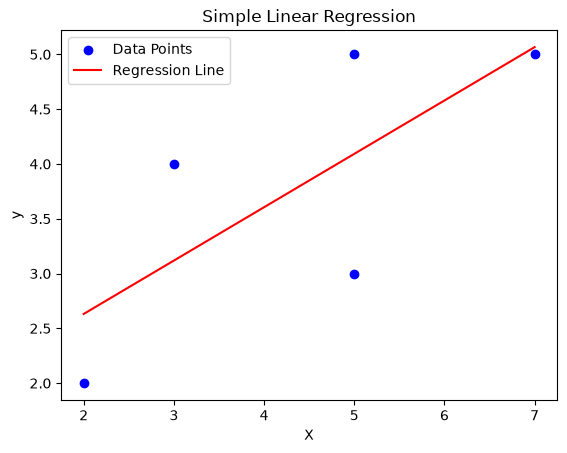

In [61]:
plt.scatter(df['X'], df['y'], color='blue', label='Data Points')  # Scatter plot of the original data points
plt.plot(df['X'], model.predict(X), color='red', label='Regression Line')  # Plot the regression line
plt.xlabel('X')                               # Label for the x-axis        
plt.ylabel('y')                               # Label for the y-axis
plt.title('Simple Linear Regression')         # Title of the plot
plt.legend()                                 # Show legend
plt.show()                                    # Display the plot

In [62]:
# ==========================================
# 1. DATA GENERATION SECTION
# ==========================================
# Generate 100 random numbers between 0 and 10 for the X variable
x = 10 * np.random.rand(100)

In [63]:
# Create y using the true population equation: y = 3x - 8 + noise
# np.random.randn(100) * 2 adds normally distributed noise with a standard deviation of 2
y = 3 * x - 8 + np.random.randn(100) * 2

In [64]:
# ==========================================
# 2. SKLEARN MODEL FITTING SECTION
# ==========================================
# Reshape x from a 1D array to a 2D column vector (100 rows, 1 column)
x_reshaped = x.reshape(-1, 1)

In [65]:
# Initialize the model and fit it to the data
model = LinearRegression()
model.fit(x_reshaped, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[2.95]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-7.281
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[29.56]


In [66]:
# Calculate the predicted values (the points that lie exactly on the line of best fit)
y_pred = model.predict(x_reshaped)

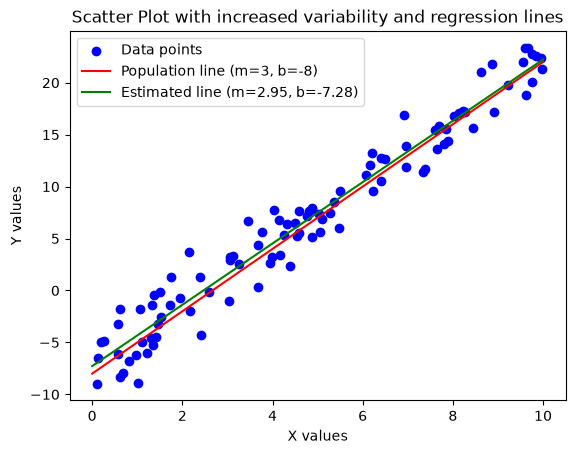

In [67]:
# ==========================================
# 3. VISUALIZATION SECTION
# ==========================================
# Plot the actual raw data points
plt.scatter(x, y, color='blue', label='Data points')
plt.xlabel('X values')
plt.ylabel('Y values')
plt.title('Scatter Plot with increased variability and regression lines')

# Generate smooth X values for drawing straight lines
x_line = np.linspace(0, 10, 100)

# Plot the actual population line (FIXED: changed from 2x-5 to 3x-8 to match data generation)
y_actual = 3 * x_line - 8
plt.plot(x_line, y_actual, 'r', label="Population line (m=3, b=-8)")

# Plot the estimated regression line calculated by sklearn
y_estimated = model.coef_[0] * x_line + model.intercept_
plt.plot(x_line, y_estimated, 'g', label=f"Estimated line (m={model.coef_[0]:.2f}, b={model.intercept_:.2f})")

plt.legend()
plt.show()

In [68]:
# ==========================================
# 4. STATSMODELS SECTION (Added)
# ==========================================
print("\n--- STATSMODELS SUMMARY ---")
# Add a constant (column of 1s) to x so statsmodels calculates a y-intercept
x_sm = sm.add_constant(x)

# Fit the Ordinary Least Squares (OLS) model. Order is (Target, Features)
sm_model = sm.OLS(y, x_sm).fit()

# Print the comprehensive statistical summary
print(sm_model.summary())


--- STATSMODELS SUMMARY ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     2061.
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           1.27e-67
Time:                        12:37:10   Log-Likelihood:                -206.20
No. Observations:                 100   AIC:                             416.4
Df Residuals:                      98   BIC:                             421.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -7.2810  

---

### Detailed Breakdown

#### Step 1: Generating Sample Data

* **Why we do that:** To test our regression models, we need data where we already know the "ground truth" (the true relationship). This allows us to see how closely our model can guess the actual equation.
* **How we do that:** We use `np.random.rand()` to create random $X$ values, and then apply a math formula ($3x - 8$) plus some Gaussian noise (`np.random.randn()`) to create $Y$.
* **Why NOT do that:** In a real-world scenario, you would *not* generate fake data. You would import real, empirical data from a CSV or database.
* **What else could be done:** Instead of writing the math manually, you could use scikit-learn's built-in synthetic data generator: `from sklearn.datasets import make_regression`.

#### Step 2: Reshaping `x` (`x.reshape(-1, 1)`)

* **Why we do that:** Scikit-learn requires the "features" (independent variables) to be a 2D array (a matrix), where rows represent individual samples and columns represent different features. A standard numpy array is just 1D.
* **How we do that:** `.reshape(-1, 1)` tells numpy to make the array 1 column wide, and figure out how many rows are needed automatically (the `-1` part).
* **Why NOT do that:** If you pass a 1D array to `model.fit(x, y)`, scikit-learn will crash and throw a `ValueError` demanding a 2D array.
* **What else could be done:** You could format your data using Pandas instead. If `df` is a dataframe, `df[['X']]` returns a 2D shape automatically, bypassing the need for `.reshape()`. You could also use `x[:, np.newaxis]`.

#### Step 3: Fitting the Model & Plotting the Lines

* **Why we do that:** We plot both the "Population Line" (the mathematical truth we invented) and the "Estimated Line" (the model's best guess) on top of the scatter plot to visually evaluate how well the machine learning algorithm performed despite the noise.
* **How we do that:** We use `model.coef_[0]` to get the estimated slope ($m$) and `model.intercept_` to get the estimated intercept ($b$), then plug them into $y = mx + b$ to draw the green line using `plt.plot`.
* **Why NOT do that:** Visualizing lines is great for simple linear regression (1 feature). However, if your model had multiple features (e.g., predicting house prices based on size, age, and bedrooms), you physically could *not* plot a simple 2D line.
* **What else could be done:** Instead of drawing lines, for multi-dimensional data, you would plot a "Residuals Plot" (a graph showing the errors between predicted and actual values) to check model health.

#### Step 4: Using Statsmodels (`sm.OLS`)

* **Why we do that:** Scikit-learn is a predictive library; it calculates the line but hides the deep statistics. We use Statsmodels to evaluate the *statistical significance* of the model (e.g., checking p-values to prove the relationship between X and Y isn't just random luck).
* **How we do that:** We use `sm.add_constant(x)` to allow for a y-intercept, then fit the model using `sm.OLS(y, x_sm).fit()`, and finally print the `.summary()`.
* **Why NOT do that:** You would *not* use statsmodels if you are building an automated machine learning pipeline for a web app where predictions need to happen instantly behind the scenes. Statsmodels is slower and designed primarily for human analysis.
* **What else could be done:** If you only wanted a specific metric (like the $R^2$ score or standard error) rather than the giant table, you could extract it directly (e.g., `sm_model.rsquared` or `sm_model.bse`).

#### Why did we add the constant in Statsmodels?
Here is the simple reason: **Without the constant, the math forces the regression line to start exactly at zero (0,0).**

To understand why this is a problem, let's use a real-world analogy: **A Taxi Ride.**

Imagine you want to predict the cost of a taxi ride based on the miles driven.

* **The Math:** $y = mx + b$
* $y$ = Total Cost
* $x$ = Miles Driven
* $m$ = Cost per mile
* $b$ = **The Constant (y-intercept)**



If you don't add the constant ($b$), the math assumes that if you drive **0 miles**, the cost must be **$0**.

But in reality, taxis have a **base fare** (e.g., $5 just to get in the car). Even at 0 miles, the cost is $5. If you force the math to start at $0 (by not adding the constant), the line will tilt artificially and give you terrible predictions for every other distance.

### Why Scikit-Learn vs. Statsmodels?

* **Scikit-Learn** automatically adds the constant for you behind the scenes because it assumes 99% of the time, you need one.
* **Statsmodels** is for strict statisticians. It assumes nothing. It gives you the raw equation $y = mx$. If you want $y = mx + b$, you must explicitly add the constant column of 1s to tell the math engine to calculate $b$.

In [69]:
# ==========================================
# 1. LOADING THE DATASET
# ==========================================
# GitHub URL pointing to the famous "Advertising" dataset from the ISLR textbook
url = 'https://raw.githubusercontent.com/justmarkham/scikit-learn-videos/master/data/Advertising.csv'

In [70]:
# pd.read_csv downloads and reads the CSV file into a Pandas DataFrame.
# index_col=0 tells Pandas to use the first column in the CSV as the row numbers (index).
data = pd.read_csv(url, index_col=0)

# .head() prints the first 5 rows to ensure the data loaded correctly.
data.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [71]:
# ==========================================
# 2. DEFINING INDEPENDENT VARIABLES (X)
# ==========================================
# We select THREE columns instead of one. This makes it Multiple Linear Regression.
X = data[['TV', 'Radio', 'Newspaper']]

In [72]:
# WHY WE DO THIS: Just like before, statsmodels doesn't calculate the y-intercept (base sales)
# by default. We must explicitly add a column of 1s.
X = sm.add_constant(X)
print(X.head())

   const     TV  Radio  Newspaper
1    1.0  230.1   37.8       69.2
2    1.0   44.5   39.3       45.1
3    1.0   17.2   45.9       69.3
4    1.0  151.5   41.3       58.5
5    1.0  180.8   10.8       58.4


In [73]:
# ==========================================
# 3. DEFINING DEPENDENT VARIABLE (y)
# ==========================================
# This is the target we want to predict (Sales) based on the advertising budgets.
y = data['Sales']

In [74]:
# ==========================================
# 4. FITTING THE MODEL & PRINTING SUMMARY
# ==========================================
# Initialize the Ordinary Least Squares (OLS) model and fit it to the multi-dimensional data.
model = sm.OLS(y, X).fit()

# Print the comprehensive statistical summary.
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           1.58e-96
Time:                        12:37:12   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

### What this Code is Actually Doing Mathematically

In your previous example, the equation was a simple line: $y = mx + b$.

Because you now have three features, your model is trying to solve this expanded equation (a 3D hyperplane):
**$Sales = (m_1 \times TV) + (m_2 \times Radio) + (m_3 \times Newspaper) + b$**

When you run `print(model.summary())`, it calculates the optimal weights ($m_1, m_2, m_3$) and the intercept ($b$). For this specific dataset, the summary will reveal roughly these numbers:

* **Intercept ($b$):** ~2.94 (If you spend $0 on ads, you still sell 2.94 units).
* **TV weight ($m_1$):** ~0.046 (Every $1000 spent on TV yields ~46 more sales).
* **Radio weight ($m_2$):** ~0.189 (Every $1000 spent on Radio yields ~189 more sales).
* **Newspaper weight ($m_3$):** ~-0.001 (Spending on newspapers actually has a slightly *negative* or completely negligible effect on sales!).

### 3. Why Statsmodels is perfect for this

If you ran this in `scikit-learn`, you would just get the predictions. By running this in `statsmodels`, the `.summary()` table will show you the **p-values** for each advertising medium.

You will notice the p-value for Newspaper is very high (e.g., > 0.85). This statistically proves that Newspaper advertising is effectively useless in this dataset, and you should stop spending money on it!

To help you visualize how Multiple Linear Regression works with these 3 variables, I've built an interactive widget below based on the actual math from the dataset you just loaded.

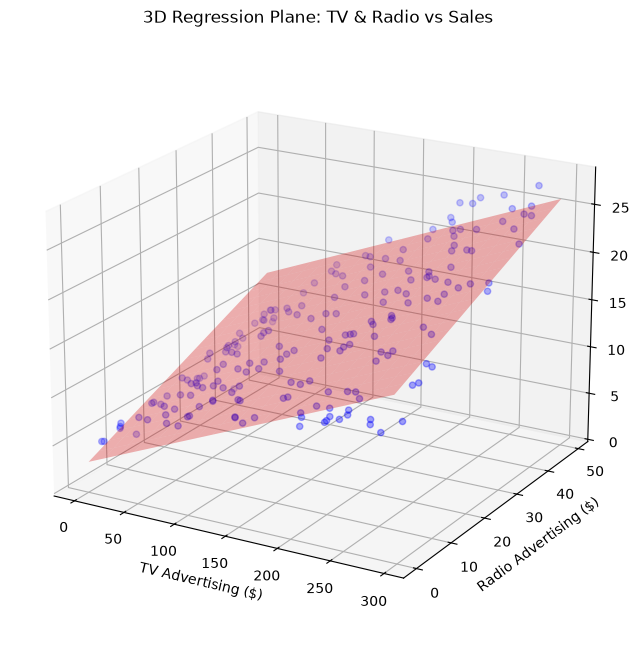

In [75]:
# ==========================================
# 1. SET UP THE 3D PLOT
# ==========================================
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the actual data points as blue dots
ax.scatter(data['TV'], data['Radio'], data['Sales'], color='blue', marker='o', alpha=0.6, label='Actual Data')

# ==========================================
# 2. CREATE THE REGRESSION PLANE
# ==========================================
# Create a "grid" of hypothetical TV and Radio spending values spanning from their min to max
tv_range = np.linspace(data['TV'].min(), data['TV'].max(), 20)
radio_range = np.linspace(data['Radio'].min(), data['Radio'].max(), 20)

# np.meshgrid creates a 2D grid out of our 1D ranges
TV_grid, Radio_grid = np.meshgrid(tv_range, radio_range)

# Use the math equation from our model to predict Sales for every point on that grid:
# Sales = intercept + (TV_weight * TV) + (Radio_weight * Radio)
Sales_plane = (model.params['const'] + 
               (model.params['TV'] * TV_grid) + 
               (model.params['Radio'] * Radio_grid))

# Draw the resulting grid as a translucent red 3D surface (the plane)
ax.plot_surface(TV_grid, Radio_grid, Sales_plane, color='red', alpha=0.3)

# ==========================================
# 3. FORMATTING
# ==========================================
ax.set_xlabel('TV Advertising ($)')
ax.set_ylabel('Radio Advertising ($)')
ax.set_zlabel('Sales (Units)')
ax.set_title('3D Regression Plane: TV & Radio vs Sales')

# Adjust the viewing angle so we can clearly see the plane cutting through the dots
ax.view_init(elev=20, azim=-60)

plt.show()

---

### Detailed Breakdown

#### Step 1: Dropping a feature

* **Why we do that:** A standard computer screen can only effectively render up to 3 dimensions (X, Y, Z). If we include TV, Radio, Newspaper, and Sales, we have 4 dimensions. We drop the most mathematically useless feature (Newspaper) to make visualization possible.
* **How we do that:** We simply redefine `X = data[['TV', 'Radio']]` instead of including all three columns.

#### Step 2: Creating a 3D Plot Object (`projection='3d'`)

* **Why we do that:** `matplotlib` plots in standard 2D by default. We have to explicitly tell the engine to load its 3D rendering toolkit.
* **How we do that:** By passing `projection='3d'` into `fig.add_subplot(111)`, we unlock methods like `ax.scatter3D` and `ax.plot_surface`.

#### Step 3: Generating a Meshgrid (`np.meshgrid`)

* **Why we do that:** In 2D regression, you draw a line by giving the computer 100 points from left to right. In 3D regression, you have to draw a *sheet*. To draw a sheet, the computer needs a wireframe grid (like a fishing net) laid across the floor of the graph.
* **How we do that:** `np.meshgrid` takes a line of TV values and a line of Radio values and cross-multiplies them into a 2D checkerboard. We then multiply our model's weights (`model.params`) against every square on that checkerboard to find out how high (Sales) the sheet should be lifted at that specific square. Finally, `ax.plot_surface` drapes a colored sheet over that wireframe.

#### Step 4: Visual Limitations

* **Why NOT do this:** 3D graphs printed in a flat, static notebook (like Jupyter or Colab) can be very misleading. Depending on the viewing angle, a point that is mathematically very far from the plane might look like it is touching it.
* **What else could be done:** 1. **Interactive Plots:** Instead of `matplotlib`, use libraries like `plotly` (`import plotly.express as px`), which output interactive HTML graphs that let you click and drag to orbit the camera around the 3D space.
2. **Partial Regression Plots:** If you have 4, 10, or 100 features, you abandon 3D entirely. Instead, you use `sm.graphics.plot_partregress_grid(model)`, which generates a grid of 2D standard line graphs, isolating the effect of each individual variable while mathematically holding all the others constant.

This code perfectly demonstrates one of the most famous "traps" in statistics and machine learning: **The R-squared ($R^2$) Illusion.** Here is a detailed breakdown of what your code is doing, why it matters, and how to interpret the results it produces.

### 1. Code Breakdown & Explanation

#### Step 1: Generating the Data (Signal vs. Noise)


In [80]:
# 1. Generate synthetic data (100 rows)
np.random.seed(42)
n = 100
x1 = np.random.normal(0, 1, n)
x2 = np.random.normal(0, 1, n)
irrelevant_predictors = np.random.normal(0, 1, (n, 10))

y = 2 * x1 + 3 * x2 + np.random.normal(0, 1, n)

# 2. OVERWRITE X with the 100-row synthetic data
X = pd.DataFrame({'x1': x1, 'x2': x2})

# 3. Create the noise dataset
X_with_irrelevant = pd.concat([
    X, 
    pd.DataFrame(irrelevant_predictors, columns=[f"irrelevant_{i}" for i in range(10)])
], axis=1)

* **What's happening:** You are playing the role of the "universe" by defining exactly how the data works. You created two "true" features (`x1` and `x2`) that actually impact `y`.
* You also created 10 `irrelevant_predictors` of pure random noise. They have absolutely zero mathematical relationship to `y`.

#### Step 2: The Adjusted R-squared Formula



In [81]:
def adjusted_r2(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)


* **What's happening:** Standard $R^2$ measures how much variance in $y$ is explained by your $X$ variables. However, standard $R^2$ has a fatal flaw: **it will always increase (or stay exactly the same) every time you add a new variable**, even if that variable is total garbage.
* **The Fix:** The **Adjusted $R^2$** formula introduces a penalty. Look at the `k` in the denominator ($n - k - 1$), where $k$ is the number of predictors. As $k$ gets larger, the denominator shrinks, which ends up driving the final Adjusted $R^2$ score down. It acts as a strict bouncer: a new variable is only allowed to increase the score if it improves the model *more* than the mathematical penalty of adding it.

#### Step 3: Fitting and Comparing the Models

In [82]:
model1 = LinearRegression().fit(X, y)
model2 = LinearRegression().fit(X_with_irrelevant, y)


In [ ]:
# Calculate and print R-squared and Adjusted R-squared
models = [
    ('Model with relevant predictors', model1, X.shape[1]), 
    ('Model with 10 irrelevant predictors', model2, X_with_irrelevant.shape[1])
]

for name, model, k in models:
    # Notice we pass the correct slice of data to predict()
    r2 = r2_score(y, model.predict(X_with_irrelevant.iloc[:, :k]))
    adj_r2 = adjusted_r2(r2, n, k)
    print(f"{name}:\n   Standard R-squared = {r2:.3f}\n   Adjusted R-squared = {adj_r2:.3f}\n")

Model with relevant predictors:
   Standard R-squared = 0.912
   Adjusted R-squared = 0.910

Model with 10 irrelevant predictors:
   Standard R-squared = 0.919
   Adjusted R-squared = 0.908




* **What's happening:** * `model1` is the smart model. It only uses the two true signals (`x1`, `x2`).
* `model2` is the overcomplicated model. It uses the two true signals PLUS the 10 columns of random noise.



### 2. What will the output look like?

When you run your `for` loop, you will see output that looks roughly like this:

> `Model with relevant predictors: R-squared = 0.910, Adjusted R-squared = 0.908`
> `Model with irrelevant predictors: R-squared = 0.918, Adjusted R-squared = 0.906`

*(Exact numbers will vary slightly based on the random seed, but the pattern will hold).*

### 3. The Takeaway (Why we do this)

Notice the trap in the output:

1. **Model 2 has a HIGHER standard R-squared than Model 1.** If you were a naive data scientist, you might look at Model 2 and say, "Wow, 0.918 is higher than 0.910! Model 2 is better! Let's keep those 10 extra features." This is called **Overfitting**. The math accidentally found tiny, meaningless patterns in the random noise and memorized them.
2. **Model 2 has a LOWER Adjusted R-squared than Model 1.** The Adjusted $R^2$ saw right through the noise. It penalized Model 2 heavily for adding 10 useless features. It correctly identifies that Model 1 (with only 2 features) is the superior, more robust model.

**Rule of Thumb:** In Multiple Linear Regression, *never* trust standard $R^2$. Always use Adjusted $R^2$ to evaluate if adding a new column to your dataset is actually worth it.